In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
from pathlib import Path

pd.set_option('display.max_columns', None)

# Download dataset and get path
dataset_path = kagglehub.dataset_download("saurabhshahane/fake-news-classification")

# Find CSV file(s) in the dataset
csv_files = list(Path(dataset_path).rglob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {dataset_path}")

# Load first CSV (or combine multiple if needed, e.g. Fake.csv + True.csv)
# index_col=0 skips the "Unnamed: 0" column (saved index from original CSV)
if len(csv_files) == 1:
    df = pd.read_csv(csv_files[0], index_col=0)
else:
    # If dataset has separate Fake.csv and True.csv, load and combine
    dfs = []
    for f in csv_files:
        dfs.append(pd.read_csv(f, index_col=0))
    df = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(df)} rows from {[f.name for f in csv_files]}")
df.head()


100%|██████████| 92.1M/92.1M [00:00<00:00, 111MB/s]

Extracting files...


Loaded 72134 rows from ['WELFake_Dataset.csv']


,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
df.shape

(72134, 3)

In [ ]:
# df.isna().sum() / len(df)

In [ ]:
df_cleaned = df[~df.isna().any(axis = 1)].copy()

In [ ]:
df_cleaned['label'].value_counts(normalize=True)

,proportion
label,
1,0.510351
0,0.489649


In [ ]:
df_cleaned

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1
...,...,...,...
72129,Russians steal research on Trump in hack of U....,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,WATCH: Giuliani Demands That Democrats Apolog...,"You know, because in fantasyland Republicans n...",1
72131,Migrants Refuse To Leave Train At Refugee Camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,Trump tussle gives unpopular Mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


# Baseline TFIDF + Logistic Regression

## Pre-processing

In [ ]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

def preprocess_text(text):
    if not isinstance(text, str):
        return ""

    # 1. Convert to Lowercase
    text = text.lower()

    # 2. Remove URLs, HTML tags, and non-alphabetic characters
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Remove Stopwords and Punctuation
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    # 5. Lemmatization
    # Reduces words to their dictionary base (e.g., "running" to "run")
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

df_cleaned['clean_title'] = df_cleaned['title'].apply(preprocess_text)
df_cleaned['clean_text'] = df_cleaned['text'].apply(preprocess_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# TF-IDF is effective for this baseline because it penalizes common words and highlights unique terms that may characterize "fake" vs. "real" reporting styles.
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# 1. Dataset Partitioning
X = df_cleaned['clean_text']
y = df_cleaned['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Vectorization (TF-IDF)
# ngram_range=(1,2) captures both individual words and two-word phrases
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 3. Model Initialization and Training
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# 4. Model Evaluation
predictions = model.predict(X_test_tfidf)

print(f"TF-IDF + Logistic Regression Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:\n", classification_report(y_test, predictions))

TF-IDF + Logistic Regression Accuracy: 0.9471

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95      7006
           1       0.94      0.96      0.95      7302

    accuracy                           0.95     14308
   macro avg       0.95      0.95      0.95     14308
weighted avg       0.95      0.95      0.95     14308



In [ ]:
# =========================
# Logistic Regression Baseline Evaluation
# =========================

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

# 1. Dataset splits (Train / Validation / Test)
X = df_cleaned['clean_text']
y = df_cleaned['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

# 2. TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

# 3. Train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# 4. Validation F1
val_pred = model.predict(X_val_tfidf)
val_f1 = f1_score(y_val, val_pred)

# 5. Test predictions
test_pred = model.predict(X_test_tfidf)
test_prob = model.predict_proba(X_test_tfidf)[:,1]

# 6. Test metrics
test_accuracy = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred)
test_precision = precision_score(y_test, test_pred)
test_recall = recall_score(y_test, test_pred)
test_auc = roc_auc_score(y_test, test_prob)

# 7. Print results
print("Validation F1:", round(val_f1,4))
print("Test Accuracy:", round(test_accuracy,4))
print("Test F1:", round(test_f1,4))
print("Precision:", round(test_precision,4))
print("Recall:", round(test_recall,4))
print("AUC:", round(test_auc,4))

Validation F1: 0.9464
Test Accuracy: 0.9453
Test F1: 0.9469
Precision: 0.9377
Recall: 0.9563
AUC: 0.987


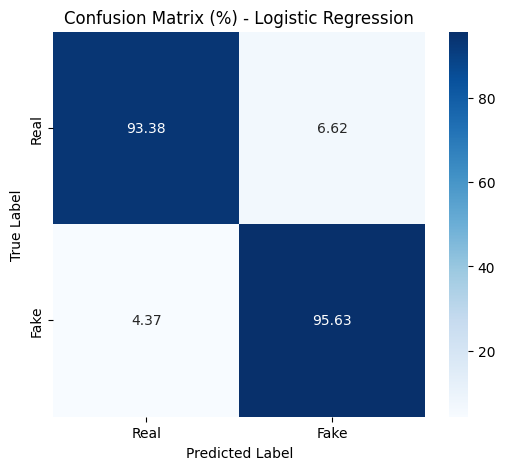

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(y_test, test_pred)

# Convert to percentages (row-wise)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix (%) - Logistic Regression")
plt.show()

# Baseline TFIDF + Tree Models

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 1. Random Forest Implementation
# n_estimators=100 creates an ensemble of 100 decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)
rf_preds = rf_model.predict(X_test_tfidf)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print("\nClassification Report:\n", classification_report(y_test, rf_preds))

# 2. XGBoost Implementation (Gradient Boosting)
# Useful for handling imbalanced data and complex patterns
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_tfidf, y_train)
xgb_preds = xgb_model.predict(X_test_tfidf)

print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print("\nClassification Report:\n", classification_report(y_test, xgb_preds))

Random Forest Accuracy: 0.9486

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.93      0.95      7006
           1       0.94      0.97      0.95      7302

    accuracy                           0.95     14308
   macro avg       0.95      0.95      0.95     14308
weighted avg       0.95      0.95      0.95     14308



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:30:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9590

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96      7006
           1       0.95      0.98      0.96      7302

    accuracy                           0.96     14308
   macro avg       0.96      0.96      0.96     14308
weighted avg       0.96      0.96      0.96     14308



# NB just for fun

In [ ]:
from sklearn.naive_bayes import MultinomialNB

# 1. Model Initialization
# alpha=1.0 is the Laplace smoothing parameter, which prevents
# zero probabilities for words not seen in the training set.
nb_model = MultinomialNB(alpha=1.0)

# 2. Model Training
# Using the same TF-IDF vectorized data from your previous steps
nb_model.fit(X_train_tfidf, y_train)

# 3. Model Prediction and Evaluation
nb_preds = nb_model.predict(X_test_tfidf)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds):.4f}")
print("\nClassification Report:\n", classification_report(y_test, nb_preds))

Naive Bayes Accuracy: 0.8513

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.82      0.84      7006
           1       0.83      0.88      0.86      7302

    accuracy                           0.85     14308
   macro avg       0.85      0.85      0.85     14308
weighted avg       0.85      0.85      0.85     14308



# Baseline DL Model: Average Word2Vec + MLP

## Pre-processing

- Minimal Cleaning: We keep stopwords and punctuation that might signal tone.
- Vocabulary Mapping: We build a word_to_index map.
- Padding: Since neural networks require uniform input shapes, we pad shorter articles with zeros and truncate longer ones to a fixed max_length.

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Parameters
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 300  # Number of words per article

# 1. Initialize Tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df_cleaned['text']) # Fit on the 'raw' text

# 2. Convert text to sequences of integers
sequences = tokenizer.texts_to_sequences(df_cleaned['text'])

# 3. Pad/Truncate sequences
# Padding 'post' means zeros are added to the end of shorter texts
X_dl = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# Train/test split (same indices for sequence models + transformer)
# Use _seq for padded sequences, _text for raw text (transformer uses _text + y_train_seq/y_test_seq)
y = df_cleaned['label'].values
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)
X_train_seq = X_dl[train_idx]
X_test_seq = X_dl[test_idx]
y_train_seq = y[train_idx]
y_test_seq = y[test_idx]
# Same split as text for BERT/transformer (so all DL models use the same train/test split)
X_train_text = df_cleaned['text'].iloc[train_idx].values
X_test_text = df_cleaned['text'].iloc[test_idx].values

print(f"Shape of Data Tensor: {X_dl.shape}")
print(f"X_train_seq: {X_train_seq.shape}, X_test_seq: {X_test_seq.shape}")

Shape of Data Tensor: (71537, 300)
X_train_seq: (57229, 300), X_test_seq: (14308, 300)


In [ ]:
# Calculates the semantic average of an article. If an article has 100 words, we take their 100 Word2Vec vectors and compute the mean to get one single representative vector. This is then fed into a standard Multi-Layer Perceptron (MLP).
!pip install gensim
from gensim.models import Word2Vec
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 1. Train Word2Vec on your corpus (or use pre-trained)
# Each word is represented by a 100-dimensional dense vector
w2v_model = Word2Vec(sentences=[text.split() for text in df_cleaned['text']],
                     vector_size=100, window=5, min_count=2, workers=4)

# 2. Function to average word vectors for a document
def get_average_word2vec(tokens, model, vector_size):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

# 3. Create the input matrix (Average Embeddings)
X_avg_w2v = np.array([get_average_word2vec(text.split(), w2v_model, 100) for text in df_cleaned['text']])

# 4. Define the MLP Baseline
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(100,)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid') # Binary Classification
])

mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# MLP uses its own split (on Word2Vec features) so we don't overwrite X_train/X_test used by sequence models
X_w2v = X_avg_w2v
y_w2v = df_cleaned['label'].values
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, y_w2v, test_size=0.2, random_state=42, stratify=y_w2v
)

# 3. Train the MLP
early_stop = EarlyStopping(
    monitor='val_loss', patience=2, restore_best_weights=True
)
mlp_history = mlp_model.fit(
    X_train_w2v, y_train_w2v,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# 4. Predict on test set
y_pred_prob = mlp_model.predict(X_test_w2v).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

Epoch 1/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.8196 - loss: 0.3888 - val_accuracy: 0.9319 - val_loss: 0.1842
Epoch 2/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9283 - loss: 0.1809 - val_accuracy: 0.9387 - val_loss: 0.1563
Epoch 3/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9367 - loss: 0.1572 - val_accuracy: 0.9443 - val_loss: 0.1425
Epoch 4/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9462 - loss: 0.1413 - val_accuracy: 0.9455 - val_loss: 0.1473
Epoch 5/5
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9466 - loss: 0.1381 - val_accuracy: 0.9504 - val_loss: 0.1304
448/448 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
print("Test accuracy:", accuracy_score(y_test_w2v, y_pred))
print(classification_report(y_test_w2v, y_pred))

Test accuracy: 0.9521945764607213
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      7006
           1       0.95      0.96      0.95      7302

    accuracy                           0.95     14308
   macro avg       0.95      0.95      0.95     14308
weighted avg       0.95      0.95      0.95     14308



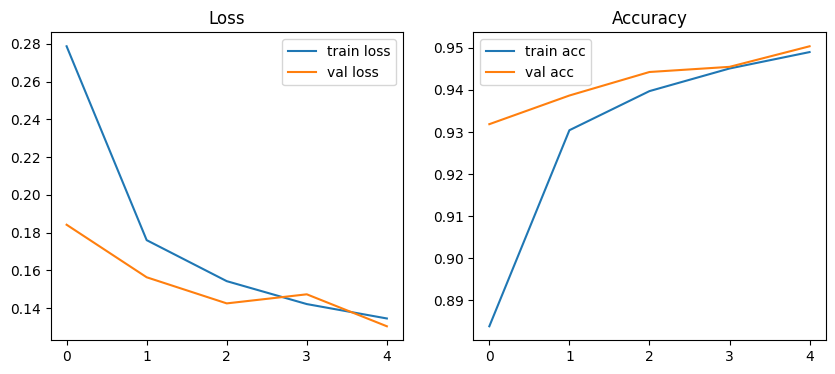

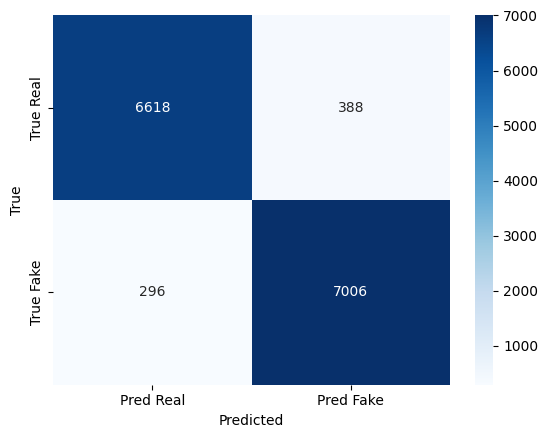

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(mlp_history.history['loss'], label='train loss')
plt.plot(mlp_history.history['val_loss'], label='val loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(mlp_history.history['accuracy'], label='train acc')
plt.plot(mlp_history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title('Accuracy')

plt.show()

cm = confusion_matrix(y_test_w2v, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Real','Pred Fake'],
            yticklabels=['True Real','True Fake'])
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()